In [2]:
import pandas as pd
import re
from astropy.io import fits
import astropy.units
from astropy.table import Table 
import numpy as np

import matplotlib.pyplot as plt
from collections import Counter
from scipy import stats
from astropy.cosmology import Planck18 as cosmo

In [3]:
pd.set_option("display.max_rows", None)
pd.set_option('display.max_columns', None)

## MY DATA

In [4]:
file_name = fr'G:\Supernova_project\Data\thesis_plots\all_data_updated.txt'
transients_filtered = pd.read_csv(file_name, header = 0, sep=r'\t+', keep_default_na=False)
transients_filtered.columns

C:\Users\Rujuta\AppData\Local\Temp\ipykernel_34788\2946373365.py:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  transients_filtered = pd.read_csv(file_name, header = 0, sep=r'\t+', keep_default_na=False)


Index(['Transient', 'Type', 'z', 'N_id', 'F090W', 'F115W', 'F150W', 'F200W',
       'F277W', 'F356W', 'F444W', 'F090W_AB', 'F090W_ABerr', 'F115W_AB',
       'F115W_ABerr', 'F150W_AB', 'F150W_ABerr', 'F200W_AB', 'F200W_ABerr',
       'F277W_AB', 'F277W_ABerr', 'F356W_AB', 'F356W_ABerr', 'F444W_AB',
       'F444W_ABerr', 'F090W_M', 'F115W_M', 'F150W_M', 'F200W_M', 'F277W_M',
       'F356W_M', 'F444W_M', 'M_blue', 'M_IR', 'blue', 'ir', 'offset_arc',
       'offset_kpc', 'r50_arc', 'r50_kpc', 'R_norm'],
      dtype='object')

## JADES CATALOG GALAXIES

In [25]:
jades = pd.read_csv(fr"G:\Supernova_project\Data\thesis_plots\comparison_samples\jades_galaxies.txt", header=0, sep=r'\t+')


C:\Users\Rujuta\AppData\Local\Temp\ipykernel_30728\1809883996.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  jades = pd.read_csv(fr"G:\Supernova_project\Data\thesis_plots\comparison_samples\jades_galaxies.txt", header=0, sep=r'\t+')


## Transients with spiral host galaxies 

In [83]:
spirals_goodsS = ["AT2022aeiv", "AT2022aeiw", "AT2022aewq", "AT2023adtv", "AT2022aevs", "AT2022aewj", "AT2022aewl", "AT2022aewm", "AT2022aewk", "AT2022aewr", "AT2023adtj", "AT2023adty", "AT2023vnz"]
interacting_goodsS = ["AT2022aewd", "AT2022aewi", "AT2022aevp", "AT2022aevu", "AT2022aewv", "AT2023adth", "AT2023adtn", "AT2023vny", "AT2023voc", "AT2022aewn"]

spirals_goodsN = ["AT2023adyi", "AT2023adyo", "AT2023adyp", "AT2023adyt", "AT2023adyq", "AT2023adya", "AT2023jxw", "AT2023jyh", "AT2023jyk", "AT2024vqi", "AT2024vqk", "AT2024vql", "AT2024vqn"]
interacting_goodsN = ["AT2023adyq", "AT2023jxw", "AT2023jyk", "AT2023jyl", "AT2024vqc", "AT2024vqe"]

spirals_all = ["AT2022aeiv", "AT2022aeiw", "AT2022aewq", "AT2023adtv", "AT2022aevs", "AT2022aewj", "AT2022aewl", "AT2022aewm", "AT2022aewk", "AT2022aewr", "AT2023adtj", "AT2023adty", "AT2023vnz", "AT2023adyi", "AT2023adyo", "AT2023adyp", "AT2023adyt", "AT2023adyq", "AT2023adya", "AT2023jxw", "AT2023jyh", "AT2023jyk", "AT2024vqi", "AT2024vqk", "AT2024vql", "AT2024vqn"]

interacting_all = ["AT2022aewd", "AT2022aewi", "AT2022aevp", "AT2022aevu", "AT2022aewv", "AT2023adth", "AT2023adtn", "AT2023vny", "AT2023voc", "AT2022aewn", "AT2023adyq", "AT2023jxw", "AT2023jyk", "AT2023jyl", "AT2024vqc", "AT2024vqe"]

# Dataframe to select column I want to plot

In [69]:
pass_filter = "r50_kpc"
flights = transients_filtered[["Transient", "Type", "z", f"{pass_filter}"]]
flights.columns

Index(['Transient', 'Type', 'z', 'r50_kpc'], dtype='object')

## B16 LGRBs 

In [6]:
b16 = pd.read_csv(fr'G:\Supernova_project\Data\thesis_plots\comparison_samples\b16_lgrbs.txt', header = 0)
b16.columns

Index(['GRB', 'R_phys', 'R_phys_err', 'R_norm', 'R_norm_err', 'z', 'Rh',
       'r50_kpc', 'Flight', 'Ratio_leq_0.1'],
      dtype='object')

In [7]:
grbs_b16 = b16[b16["Ratio_leq_0.1"] == True ]

In [22]:
grbs_b16

,GRB,R_phys,R_phys_err,R_norm,R_norm_err,z,Rh,r50_kpc,Flight,Ratio_leq_0.1
0,040924,2.197,0.116,1.521,0.080,0.859,0.188,1.486,0.783,True
1,050315,0.953,0.474,0.481,0.239,1.949,0.236,2.030,0.693,True
2,050401,0.638,0.397,0.483,0.300,2.900,0.170,1.353,0.799,True
4,050408,1.263,0.239,0.545,0.103,1.236,0.278,2.377,0.724,True
5,050416A,0.260,0.090,0.234,0.081,0.654,0.160,1.145,0.896,True
6,050525,0.185,0.046,0.232,0.057,0.606,0.119,0.823,0.914,True
7,050820,3.530,0.081,3.808,0.087,2.612,0.116,0.949,0.606,True
8,050824,3.597,0.410,1.177,0.134,0.830,0.402,3.143,0.324,True
9,050904,0.774,0.205,0.928,0.246,6.290,0.150,0.852,0.374,True
14,060124,0.278,0.291,0.197,0.206,2.296,0.172,1.446,0.882,True


## Perley GRBs 

In [31]:
perley_grbs = pd.read_csv(fr'G:\Supernova_project\Data\perley2015_clean.txt', header=0)
perley_grbs.columns

Index(['GRB', 'z', 'mag_val', 'mag_err', 'upper_limit', 'lower_limit'], dtype='object')

## K08 CCNSe - Only Flights

In [18]:
kelly = pd.read_csv(fr"G:\Supernova_project\Data\thesis_plots\comparison_samples\kelly2008.txt", sep=r'\s+', keep_default_na=False)
kelly.columns

Index(['Transient', 'Type', 'Flight'], dtype='object')

In [55]:
kelly_II = kelly.loc[kelly["Type"] == "II", f"Flight"].astype(float).round(2)
kelly_Ib = kelly.loc[kelly["Type"] == "Ib", f"Flight"].astype(float).round(2)
kelly_Ic = kelly.loc[kelly["Type"] == "Ic", f"Flight"].astype(float).round(2)
kelly_Ibc = kelly.loc[kelly["Type"].isin(["Ib", "Ic", "Ibc"]), f"Flight"].astype(float).round(2)
kelly_ccsne = kelly.loc[~kelly["Type"].isin(["Ia"]), f"Flight"].astype(float).round(2)


## K14 CCSNe 

In [20]:
kelly14 = pd.read_csv(fr'G:\Supernova_project\Data\thesis_plots\comparison_samples\kelly2014.txt', header = 0, sep=r'\t+', keep_default_na=False)
kelly14.columns

C:\Users\Rujuta\AppData\Local\Temp\ipykernel_34788\478137916.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  kelly14 = pd.read_csv(fr'G:\Supernova_project\Data\thesis_plots\comparison_samples\kelly2014.txt', header = 0, sep=r'\t+', keep_default_na=False)


Index(['Name', 'z', 'Type', 'Mass', 'Mass_e', 'SFR', 'SFR_e', 'Sigma_M',
       'Sigma_Merr', 'Sigma_SFR', 'SigmaSFR_err', 'r50_kpc', 'R50_err'],
      dtype='object')

In [34]:
kelly14_II = kelly14.loc[kelly14["Type"] == "II", f"r50_kpc"].astype(float).round(2).dropna()
kelly14_Ibc = kelly14.loc[kelly14["Type"].isin(["Ib", "Ic", "Ibc"]), f"r50_kpc"].astype(float).round(2).dropna()

### PLOTTING SCRIPTS

## $F_{lights}$

In [ ]:
def cdf_maker(df): 

    cdfs = df[f"{pass_filter}"].astype(float).round(2) #cdf values of all the transients rounded to two decimal places
    cdf_II = df.loc[df["Type"] == "II", f"{pass_filter}"].astype(float).round(2) #cdf values of type II SNe 
    cdf_Ibc = df.loc[df["Type"] == "Ibc", f"{pass_filter}"].astype(float).round(2) #cdf values of Ibc SNe 
    cdf_un = df.loc[df["Type"] == "Unclassified", f"{pass_filter}"].astype(float).round(2) #cdf values of Ibc SNe 

    fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 9), constrained_layout=True)

    # defining the uniform distribution
    ref = stats.uniform.rvs(size=100000)
    ref_sorted = np.sort(ref)
    ref_cdf = np.arange(0, len(ref_sorted))/len(ref_sorted)

    # considering only CCSNe
    cdfs_classified = cdf_II.to_list() + cdf_Ibc.to_list()
    sorted_classified = np.sort(cdfs_classified)
    cdf_of_cdf_classified = np.arange(0, len(sorted_classified))/len(sorted_classified)

    # cdfs for unclassified sne 
    sorted_un = np.sort(cdf_un)
    cdf_un = np.arange(0, len(sorted_un))/len(sorted_un)

    # considering SN II
    sorted_II = np.sort(cdf_II)
    cdf_II = np.arange(0, len(sorted_II))/len(sorted_II)

    # considering SN Ibc
    sorted_Ibc = np.sort(cdf_Ibc)
    cdf_Ibc = np.arange(0, len(sorted_Ibc))/len(sorted_Ibc)

    # comparison sample LGRBs
    grbb16_sorted = np.sort(grbs_b16["Flight"])
    cdf_grbb16 = np.arange(0, len(grbb16_sorted))/len(grbb16_sorted)

    # kellyII_sorted = np.sort(kelly_II)
    # kellyII_cdf = np.arange(0, len(kellyII_sorted))/len(kellyII_sorted)

    # kellyIb_sorted = np.sort(kelly_Ib)
    # kellyIb_cdf = np.arange(0, len(kellyIb_sorted))/len(kellyIb_sorted)

    # kellyIc_sorted = np.sort(kelly_Ic)
    # kellyIc_cdf = np.arange(0, len(kellyIc_sorted))/len(kellyIc_sorted)

    # kellyIbc_sorted = np.sort(kelly_Ibc)
    # kellyIbc_cdf = np.arange(0, len(kellyIbc_sorted))/len(kellyIbc_sorted)

    # kelly_all = np.sort(kelly_ccsne)
    # kellyccsne_cdf = np.arange(0, len(kelly_all))/len(kelly_all)


    # # comparison sample FRBs 
    # frbs_sorted = np.sort(frbs_2024)
    # cdf_frbs = np.arange(0, len(frbs_sorted))/len(frbs_sorted)

    # making a plot of SN II, Ibc, and Unclassified separated
    # axes[0].plot(ref_sorted, ref_cdf, color='lightgrey') 
    # axes[0].step(sorted_II, cdf_II, color='crimson', label=fr"II ({len(sorted_II)})")
    # axes[0].step(sorted_Ibc, cdf_Ibc, color='royalblue', label=fr'Ibc ({len(sorted_Ibc)})')
    # axes[0].step(sorted_un, cdf_un, color='darkolivegreen', label=fr'Unclassified ({len(sorted_un)})')

    # axes[0].set_xlabel(r"$F_{\text{light}}$", fontsize=18)
    # axes[0].set_ylabel("Cumulative Fraction", fontsize=18)
    # axes[0].legend(fontsize=12)
    # axes[0].tick_params(axis="both", which="major", labelsize=12)


    # for IR
    # axes.plot(ref_sorted, ref_cdf, color='lightgrey') 
    # axes.step(sorted_II, cdf_II, color='crimson', label=fr"II ({len(sorted_II)})")
    # axes.step(sorted_Ibc, cdf_Ibc, color='royalblue', label=fr'Ibc ({len(sorted_Ibc)})')
    # axes.step(sorted_un, cdf_un, color='darkolivegreen', label=fr'Unclassified ({len(sorted_un)})')
    # axes.set_xlabel(r"$F_{light-IR}$", fontsize=18)
    # axes.set_ylabel("Cumulative Fraction", fontsize=18)
    # axes.legend(fontsize=12)
    # axes.tick_params(axis="both", which="major", labelsize=12)


    # adding samples from other papers
    axes.plot(ref_sorted, ref_cdf, color='lightgrey') 
    axes.step(sorted_II, cdf_II, color='crimson', label=fr"II ({len(sorted_II)})")
    axes.step(sorted_Ibc, cdf_Ibc, color='royalblue', label=fr'Ibc ({len(sorted_Ibc)})')
    axes.step(sorted_un, cdf_un, color='darkolivegreen', label=fr'Unclassified ({len(sorted_un)})')


    # axes.step(kellyII_sorted, kellyII_cdf, color="crimson", linestyle='--', label=fr'K08 SN II ({len(kelly_II)})')
    # axes.step(kellyIb_sorted, kellyIb_cdf, color="hotpink", linestyle='--', label=fr'K08 SN Ib ({len(kelly_Ib)})')
    # axes.step(kellyIc_sorted, kellyIc_cdf, color="lightskyblue", linestyle = '--', label=fr'K08 SN Ic ({len(kelly_Ic)})')
    # axes.step(kellyIbc_sorted, kellyIbc_cdf, color="royalblue", linestyle='--', label=fr'K08 SN Ibc ({len(kelly_Ibc)})')
    axes.step(sorted_classified, cdf_of_cdf_classified, color="magenta", label=fr"CCSNe ({len(sorted_classified)})" )
    # axes.step(kelly_all, kellyccsne_cdf, color="magenta", linestyle="--", label=fr"K08 CCSNe ({len(kelly_all)})")

    # # axes[1].step(s10_samp, s10_cdf, color="hotpink", label=fr'S10 CCSNe ({len(s10_samp)})' )
    axes.step(grbb16_sorted, cdf_grbb16, color='darkturquoise', linestyle='--', label=fr'B16 LGRBs ({len(grbb16_sorted)})')
    # axes.step(slsne_sorted, cdf_slsne, color='darkviolet', linestyle='--', label = fr'H24 SLSNe ({len(slsne_sorted)})')
    # # axes[1].step(frbs_sorted, cdf_frbs, color='orange', linestyle='--', label=fr'W24 FRBs ({len(frbs_sorted)})')

    axes.set_xlabel(r"$F_{light-Blue}$", fontsize=21)
    axes.set_ylabel(r"Cumulative Fraction", fontsize=21)
    axes.tick_params(axis="both", which="major", labelsize=17)
    axes.legend(fontsize=12)

    # WITH REDSHIFT BINS 
    z1_ccsne = df.loc[(df['z'] >= 0) & (df['z'] < 1.5) & (df["Type"].isin(["II", "Ibc"])), f"{pass_filter}"].astype(float).round(2)
    z1_un = df.loc[(df['z'] >= 0) & (df['z'] < 1.5) & (df["Type"] == "Unclassified"), f"{pass_filter}"].astype(float).round(2)

    z2_ccsne = df.loc[(df['z'] >= 1.5) & (df['z'] < 2.5) & (df["Type"].isin(["II", "Ibc"])), f"{pass_filter}"].astype(float).round(2)
    z2_un = df.loc[(df['z'] >= 1.5) & (df['z'] < 2.5) & (df["Type"] == "Unclassified"), f"{pass_filter}"].astype(float).round(2)

    z3_ccsne = df.loc[(df['z'] >= 2.5) & (df["Type"].isin(["II", "Ibc"])), f"{pass_filter}"].astype(float).round(2)
    z3_un = df.loc[(df['z'] >= 2.5) & (df["Type"] == "Unclassified"), f"{pass_filter}"].astype(float).round(2)
    
    fig, zaxes = plt.subplots(nrows=1, ncols=2, figsize=(13, 5), constrained_layout=True)

    print(np.mean(sorted_II))

   ## CCSNe
    sorted_z1 = np.sort(z1_ccsne)
    cdf_z1 = np.arange(0, len(z1_ccsne))/len(z1_ccsne)

    # # # cdfs for z between 1 (inclusive) and 3
    sorted_z2 = np.sort(z2_ccsne)
    cdf_z2 = np.arange(0, len(sorted_z2))/len(sorted_z2)

    sorted_z3 = np.sort(z3_ccsne)
    cdf_z3 = np.arange(0, len(sorted_z3))/len(sorted_z3)

    zaxes[0].plot(ref_sorted, ref_cdf, color='lightgrey')
    zaxes[0].step(sorted_z1, cdf_z1, color = 'orange', label= fr'$ z < 1.5 ({len(z1_ccsne)})$')
    # zaxes[0].step(s10_samp, s10_cdf, color="hotpink", label=fr'S10 CCSNe ({len(s10_samp)})' )
    zaxes[0].step(sorted_z2, cdf_z2, color = 'royalblue', label = fr'$1.5 \leq z < 2.5$ ({len(z2_ccsne)})')
    zaxes[0].step(sorted_z3, cdf_z3, color = 'mediumvioletred', label=fr'$z \geq 2.5$ ({len(z3_ccsne)})')
    zaxes[0].set_xlabel(r"$F_{\text{light}}$", fontsize=18)
    zaxes[0].set_ylabel("Cumulative Fraction", fontsize=18)
    zaxes[0].legend(fontsize=12)
    zaxes[0].tick_params(axis="both", which="major", labelsize=12)
    zaxes[0].set_title('CCSNe', fontsize=18)

    # Unclassified transients 
    sorted_z1_un = np.sort(z1_un)
    cdf_z1_un = np.arange(0, len(z1_un))/len(z1_un)

    # # # cdfs for z between 1 (inclusive) and 3
    sorted_z2_un = np.sort(z2_un)
    cdf_z2_un = np.arange(0, len(sorted_z2_un))/len(sorted_z2_un)

    sorted_z3_un = np.sort(z3_un)
    cdf_z3_un = np.arange(0, len(sorted_z3_un))/len(sorted_z3_un)

    zaxes[1].plot(ref_sorted, ref_cdf, color='lightgrey')
    zaxes[1].step(sorted_z1_un, cdf_z1_un, color = 'orange', label= fr'$ z < 1.5 ({len(z1_un)})$')
    zaxes[1].step(sorted_z2_un, cdf_z2_un, color = 'royalblue', label = fr'$1.5 \leq z < 2.5$ ({len(z2_un)})')
    zaxes[1].step(sorted_z3_un, cdf_z3_un, color = 'mediumvioletred', label=fr'$z \geq 2.5$ ({len(z3_un)})')
    zaxes[1].set_xlabel(r"$F_{\text{light}}$", fontsize=18)
    zaxes[1].legend(fontsize=12)
    zaxes[1].tick_params(axis="both", which="major", labelsize=12)
    zaxes[1].set_title('Unclassified Transients', fontsize=18)

    return 



0.39673469387755106


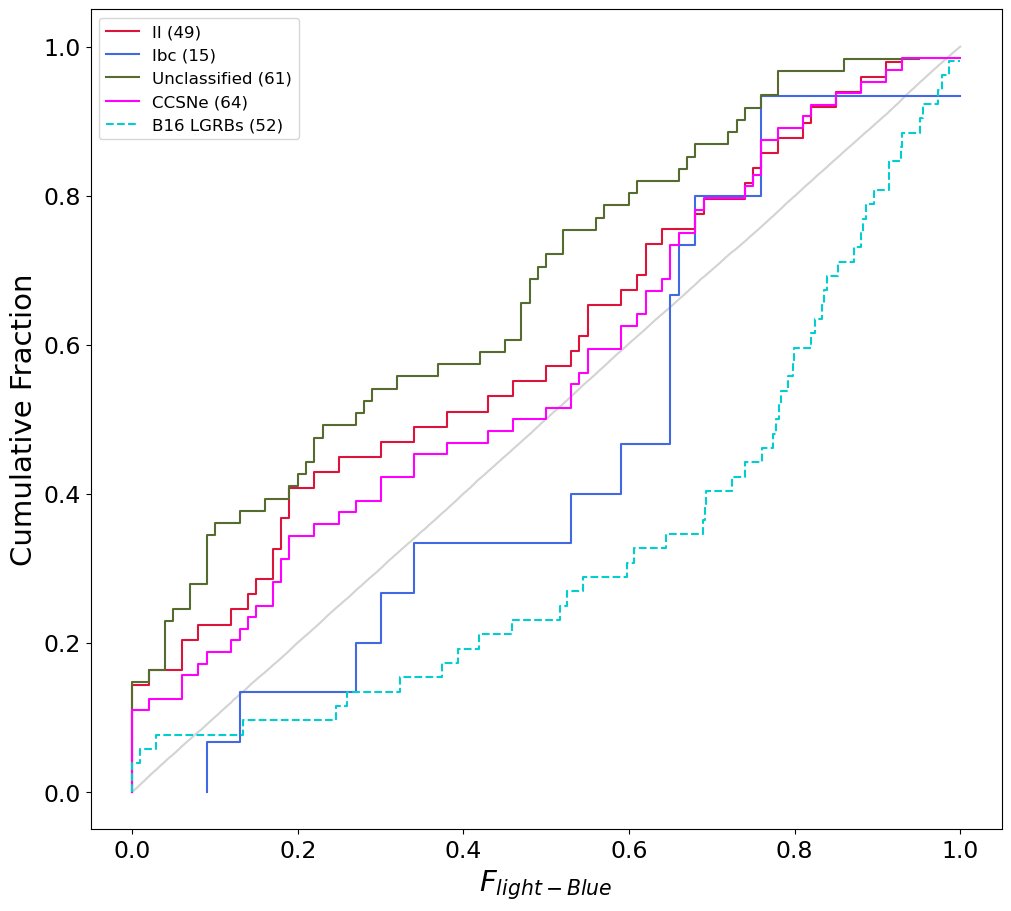

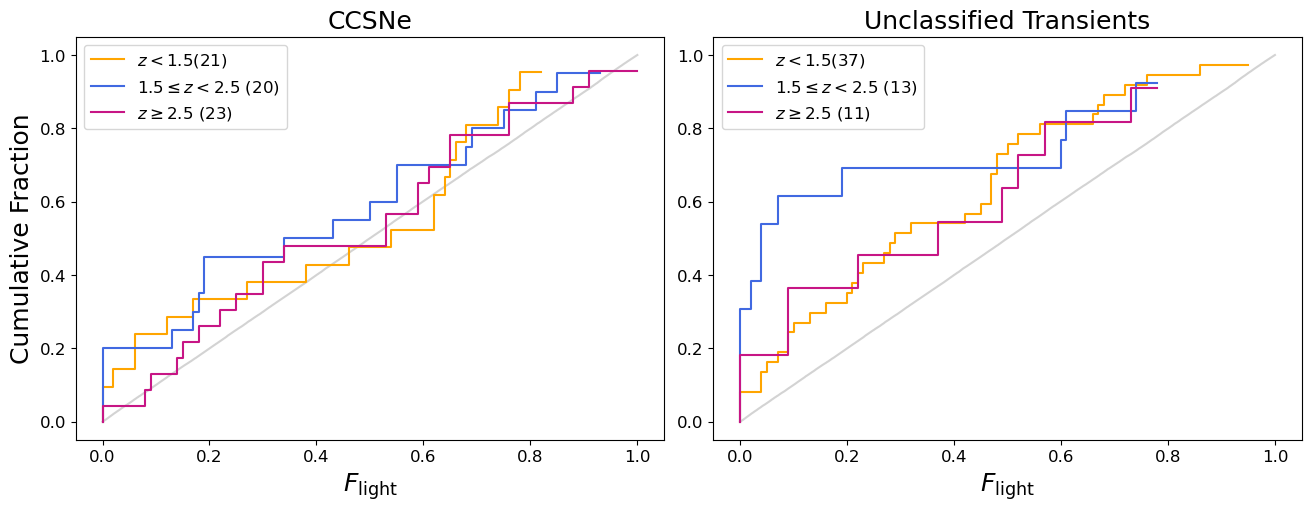

In [17]:
cdf_maker(flights)

## Projected offsets

In [ ]:
def offset_maker(df): 

    cdfs = df[f"{pass_filter}"].astype(float).round(2) #cdf values of all the transients rounded to two decimal places
    cdf_II = df.loc[df["Type"] == "II", f"{pass_filter}"].astype(float).round(2) #cdf values of type II SNe 
    cdf_Ibc = df.loc[df["Type"] == "Ibc", f"{pass_filter}"].astype(float).round(2) #cdf values of Ibc SNe 
    cdf_un = df.loc[df["Type"] == "Unclassified", f"{pass_filter}"].astype(float).round(2) #cdf values of Ibc SNe 

    fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(6.5, 5), constrained_layout=True)

    # defining the uniform distribution
    ref = stats.uniform.rvs(size=100000)
    ref_sorted = np.sort(ref)
    ref_cdf = np.arange(0, len(ref_sorted))/len(ref_sorted)

    # considering only CCSNe
    # considering SN II
    sorted_II = np.sort(cdf_II)
    cdf_II = np.arange(0, len(sorted_II))/len(sorted_II)

    # considering SN Ibc
    sorted_Ibc = np.sort(cdf_Ibc)
    cdf_Ibc = np.arange(0, len(sorted_Ibc))/len(sorted_Ibc)

    # # comparison sample LGRBs
    grbs_samp = b16['R_norm']
    # grbs_samp = b16_highz
    grbb16_sorted = np.sort(grbs_samp)
    cdf_grbb16 = np.arange(0, len(grbs_samp))/len(grbs_samp)

    # WITH REDSHIFT BINS 
    z1_ccsne = df.loc[(df['z'] >= 0) & (df['z'] < 1.5) & (df["Type"].isin(["II", "Ibc"])), f"{pass_filter}"].astype(float).round(2)
    z1_un = df.loc[(df['z'] >= 0) & (df['z'] < 1.5) & (df["Type"] == "Unclassified"), f"{pass_filter}"].astype(float).round(2)

    z2_ccsne = df.loc[(df['z'] >= 1.5) & (df['z'] < 2.5) & (df["Type"].isin(["II", "Ibc"])), f"{pass_filter}"].astype(float).round(2)
    z2_un = df.loc[(df['z'] >= 1.5) & (df['z'] < 2.5) & (df["Type"] == "Unclassified"), f"{pass_filter}"].astype(float).round(2)

    z3_ccsne = df.loc[(df['z'] >= 1.5) & (df["Type"].isin(["II", "Ibc"])), f"{pass_filter}"].astype(float).round(2)
    z3_un = df.loc[(df['z'] >= 1.5) & (df["Type"] == "Unclassified"), f"{pass_filter}"].astype(float).round(2)

    z_ccsne = df.loc[(df['z'] >= 1.5) & (df["Type"].isin(["II", "Ibc"])), f"{pass_filter}"].astype(float).round(3)
    # cdfs_classified = cdf_II.to_list() + cdf_Ibc.to_list()
    sorted_classified = np.sort(z_ccsne)
    cdf_of_cdf_classified = np.arange(0, len(sorted_classified))/len(sorted_classified)

    z1_b16 = b16.loc[((b16['z'] >= 0) & (b16['z'] < 1.5)), f"R_norm"].astype(float).round(3)
    z2_b16 = b16.loc[((b16['z'] >= 1.5) & (b16['z'] < 2.5)), f"R_norm"].astype(float).round(3)
    z3_b16 = b16.loc[(b16['z'] >= 1.5), f"R_norm"].astype(float).round(3)

    z1b16_sorted = np.sort(z1_b16)
    z2b16_sorted = np.sort(z2_b16)
    z3b16_sorted = np.sort(z3_b16)

    z1b16_cdf = np.arange(0, len(z1b16_sorted))/len(z1b16_sorted)
    z2b16_cdf = np.arange(0, len(z2b16_sorted))/len(z2b16_sorted)
    z3b16_cdf = np.arange(0, len(z3b16_sorted))/len(z3b16_sorted)

    # z_un = df.loc[(df['z'] >= 1.5) & (df["Type"] == "Unclassified"), f"{pass_filter}"].astype(float).round(3)
    sorted_un = np.sort(cdf_un)
    cdf_un = np.arange(0, len(sorted_un))/len(sorted_un)

    ##making a plot of SN II, Ibc, and Unclassified separated
    axes.step(sorted_II, cdf_II, color='crimson', label=fr"II ({len(sorted_II)})")
    # axes[0].step(sorted_classified, cdf_of_cdf_classified, color='crimson', label=fr"II, Ibc > 1 ({len(sorted_classified)})")


    axes.step(sorted_Ibc, cdf_Ibc, color='royalblue', label=fr'Ibc ({len(sorted_Ibc)})')
    axes.step(sorted_un, cdf_un, color='darkolivegreen', label=fr'Unclassified({len(sorted_un)})')
    axes.step(grbb16_sorted, cdf_grbb16, color='darkturquoise', linestyle='--', label=fr'B16 LGRBs ({len(grbb16_sorted)})')
    axes.set_xlabel(r"$R_{Norm}$", fontsize=18)
    axes.set_ylabel("Cumulative Fraction", fontsize=18)
    
    axes.tick_params(axis="both", which="major", labelsize=12)
    axes.set_xscale("log")

   ## adding samples from other papers 
    # axes[1].step(sorted_II, cdf_II, color='crimson', label=fr"II ({len(sorted_II)})")
    # axes[1].step(sorted_Ibc, cdf_Ibc, color='royalblue', label=fr'Ibc ({len(sorted_Ibc)})')
    # axes[1].step(sorted_un, cdf_un, color='darkolivegreen', label=fr'Unclassified ({len(sorted_un)})')

    # axes[1].step(slsne_sorted, cdf_slsne, color='darkviolet', linestyle='--', label = fr'H24 SLSNe ({len(slsne_sorted)})')
    # axes[1].step(frbs_sorted, cdf_frbs, color='orange', linestyle='--', label=fr'W24 FRBs ({len(frbs_sorted)})')
    # axes[1].set_xlabel(r"$R_{Norm}$ (kpc)", fontsize=16)
    # axes[1].tick_params(axis="both", which="major", labelsize=12)
    # axes[1].legend(fontsize=12)
    # axes[1].set_xscale('log')
    axes.legend(fontsize=12)

    
    
    fig, zaxes = plt.subplots(nrows=1, ncols=2, figsize=(13, 5), constrained_layout=True)

   ## CCSNe
    sorted_z1 = np.sort(z1_ccsne)
    cdf_z1 = np.arange(0, len(z1_ccsne))/len(z1_ccsne)

    # # # cdfs for z between 1 (inclusive) and 3
    sorted_z2 = np.sort(z2_ccsne)
    cdf_z2 = np.arange(0, len(sorted_z2))/len(sorted_z2)

    sorted_z3 = np.sort(z3_ccsne)
    cdf_z3 = np.arange(0, len(sorted_z3))/len(sorted_z3)

    # zaxes[0].plot(ref_sorted, ref_cdf, color='lightgrey')
    zaxes[0].step(sorted_z1, cdf_z1, color = 'orange', label= fr'$ z < 1.5 ({len(z1_ccsne)})$')
    # zaxes[0].step(sorted_z2, cdf_z2, color = 'royalblue', label = fr'$1.5 \leq z < 2.5$ ({len(z2_ccsne)})')
    zaxes[0].step(sorted_z3, cdf_z3, color = 'mediumvioletred', label=fr'$z \geq 1.5$ ({len(z3_ccsne)})')

    # B16 GRBs split by redshift 
    zaxes[0].step(z1b16_sorted, z1b16_cdf, color = 'orange', linestyle="--", label= fr'B16 $ z < 1.5 ({len(z1b16_sorted)})$')
    # zaxes[0].step(z2b16_sorted, z2b16_cdf, color = 'royalblue', linestyle="--", label = fr'B16 $1.5 \leq z < 2.5$ ({len(z2b16_sorted)})')
    zaxes[0].step(z3b16_sorted, z3b16_cdf, color = 'mediumvioletred', linestyle="--", label=fr'B16 $z \geq 1.5$ ({len(z3b16_sorted)})')


    zaxes[0].set_xlabel(r"$R_{Norm}$ (kpc)", fontsize=18)
    zaxes[0].set_ylabel("Cumulative Fraction", fontsize=18)
    zaxes[0].legend(fontsize=12)
    zaxes[0].tick_params(axis="both", which="major", labelsize=12)
    zaxes[0].set_title('CCSNe', fontsize=18)
    zaxes[0].set_xscale('log')

    # Unclassified transients 
    sorted_z1_un = np.sort(z1_un)
    cdf_z1_un = np.arange(0, len(z1_un))/len(z1_un)

    # # # cdfs for z between 1 (inclusive) and 3
    sorted_z2_un = np.sort(z2_un)
    cdf_z2_un = np.arange(0, len(sorted_z2_un))/len(sorted_z2_un)

    sorted_z3_un = np.sort(z3_un)
    cdf_z3_un = np.arange(0, len(sorted_z3_un))/len(sorted_z3_un)

    # zaxes[1].plot(ref_sorted, ref_cdf, color='lightgrey')
    zaxes[1].step(sorted_z1_un, cdf_z1_un, color = 'orange', label= fr'$ z < 1.5 ({len(z1_un)})$')
    # zaxes[1].step(sorted_z2_un, cdf_z2_un, color = 'royalblue', label = fr'$1.5 \leq z < 2.5$ ({len(z2_un)})')
    zaxes[1].step(sorted_z3_un, cdf_z3_un, color = 'mediumvioletred', label=fr'$z \geq 2.5$ ({len(z3_un)})')
    zaxes[1].step(z1b16_sorted, z1b16_cdf, color = 'orange', linestyle="--", label= fr'B16 $ z < 1.5 ({len(z1b16_sorted)})$')
    # zaxes[0].step(z2b16_sorted, z2b16_cdf, color = 'royalblue', linestyle="--", label = fr'B16 $1.5 \leq z < 2.5$ ({len(z2b16_sorted)})')
    zaxes[1].step(z3b16_sorted, z3b16_cdf, color = 'mediumvioletred', linestyle="--", label=fr'B16 $z \geq 1.5$ ({len(z3b16_sorted)})') 

    zaxes[1].set_xlabel(r"$R_{Norm}$ (kpc)", fontsize=18)
    zaxes[1].legend(fontsize=12)
    zaxes[1].tick_params(axis="both", which="major", labelsize=12)
    zaxes[1].set_title('Unclassified Transients', fontsize=18)
    zaxes[1].set_xscale('log')

    return 



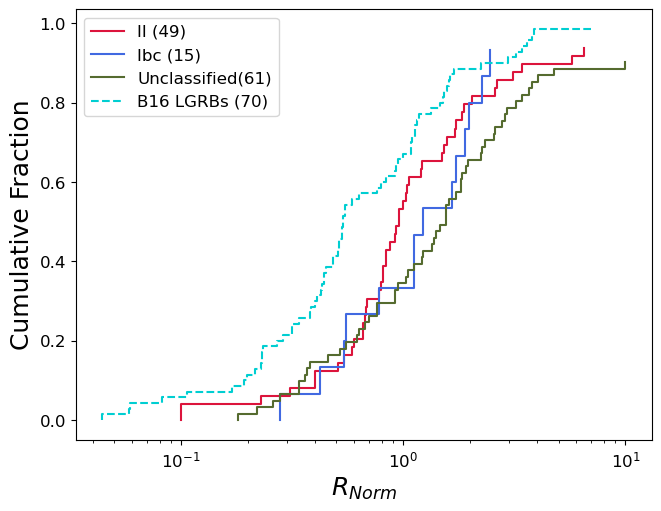

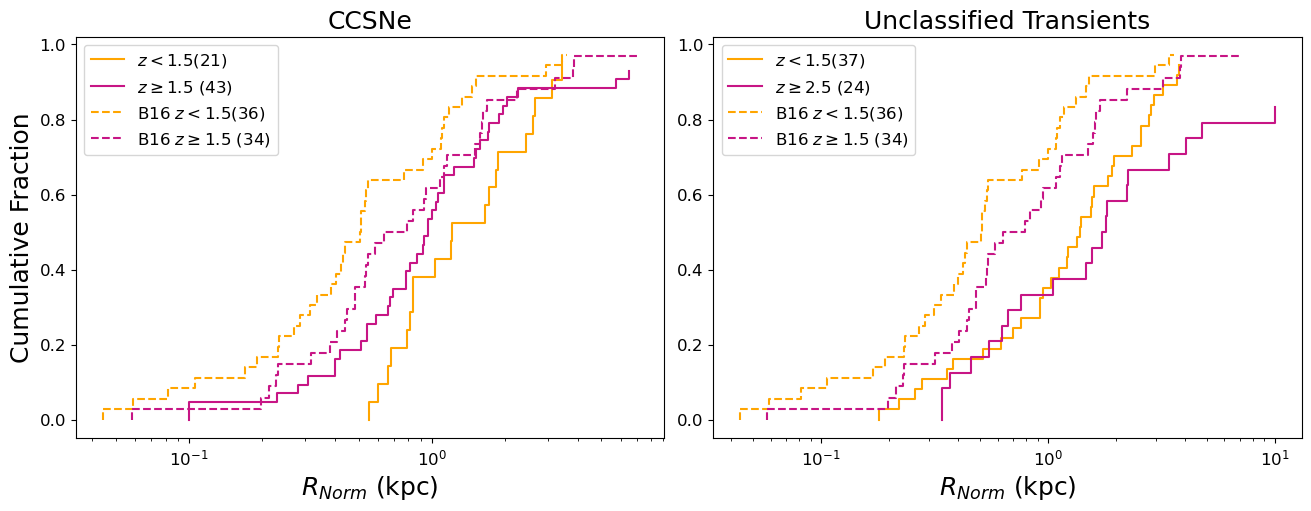

In [19]:
offset_maker(flights)

## Host Normalized Offsets

In [16]:
def rnorm_maker(df): 

    # CCSNE
    z1_ccsne = df.loc[(df['z'] >= 0) & (df['z'] < 1.5) & (df["Type"].isin(["II"])), f"{pass_filter}"].astype(float).round(3)
    z2_Ibc = df.loc[(df['z'] >= 1.5) & (df["Type"].isin(["Ibc"])), f"{pass_filter}"].astype(float).round(3)

    z1_un = df.loc[(df['z'] >= 0) & (df['z'] < 1.5) & (df["Type"] == "Unclassified"), f"{pass_filter}"].astype(float).round(3)

    z2_ccsne = df.loc[(df['z'] >= 1.5) & (df["Type"].isin(["II"])), f"{pass_filter}"].astype(float).round(3)
    
    z2_un = df.loc[(df['z'] >= 1.5) & (df["Type"] == "Unclassified"), f"{pass_filter}"].astype(float).round(3)

    sorted_z1 = np.sort(z1_ccsne)
    cdf_z1 = np.arange(0, len(z1_ccsne))/len(z1_ccsne)

    sorted_z2 = np.sort(z2_ccsne)
    cdf_z2 = np.arange(0, len(sorted_z2))/len(sorted_z2)

    sorted_z2Ibc = np.sort(z2_Ibc)
    z2Ibc_cdf = np.arange(0, len(sorted_z2Ibc))/len(sorted_z2Ibc)
    # LGRBs 

    z1_b16 = b16.loc[((b16['z'] >= 0) & (b16['z'] < 1.5) & (b16['Ratio_leq_0.1'] == True)), f"R_phys"].astype(float).round(3)
    z2_b16 = b16.loc[(b16['z'] >= 1.5) & (b16['Ratio_leq_0.1'] == True), f"R_phys"].astype(float).round(3)

    z1b16_sorted = np.sort(z1_b16)
    z2b16_sorted = np.sort(z2_b16)

    z1b16_cdf = np.arange(0, len(z1b16_sorted))/len(z1b16_sorted)
    z2b16_cdf = np.arange(0, len(z2b16_sorted))/len(z2b16_sorted)

    
    fig, zaxes = plt.subplots(nrows=1, ncols=2, figsize=(13, 5), constrained_layout=True)

    zaxes[0].step(sorted_z1, cdf_z1, color = 'crimson', label= fr'SN II, $z < 1.5 ({len(z1_ccsne)})$')
    zaxes[0].step(sorted_z2, cdf_z2, color = 'crimson', linestyle="--", label=fr'SN II, $z \geq 1.5$ ({len(z2_ccsne)})')
    zaxes[0].step(sorted_z2Ibc, z2Ibc_cdf, color= 'royalblue', linestyle = '--', label = fr'SN Ibc, $ z \geq 1.5$ ({len(sorted_z2Ibc)})')

    # B16 GRBs split by redshift 
    zaxes[0].step(z1b16_sorted, z1b16_cdf, color = 'orange', label= fr'B16 LGRBs, $ z < 1.5 ({len(z1b16_sorted)})$')
    zaxes[0].step(z2b16_sorted, z2b16_cdf, color = 'orange', linestyle="--", label = fr'B16 LGRBs, $ z \geq 1.5 $ ({len(z2b16_sorted)})')

    zaxes[0].set_xlabel(r"$R_{Norm}$", fontsize=18)
    zaxes[0].set_ylabel("Cumulative Fraction", fontsize=18)
    zaxes[0].legend(fontsize=12)
    zaxes[0].tick_params(axis="both", which="major", labelsize=12)
    zaxes[0].set_title('CCSNe', fontsize=18)
    zaxes[0].set_xscale('log')
    zaxes[0].minorticks_on()

    # Unclassified transients 
    sorted_z1_un = np.sort(z1_un)
    cdf_z1_un = np.arange(0, len(z1_un))/len(z1_un)

    # # # cdfs for z between 1 (inclusive) and 3
    sorted_z2_un = np.sort(z2_un)
    cdf_z2_un = np.arange(0, len(sorted_z2_un))/len(sorted_z2_un)

    # zaxes[1].plot(ref_sorted, ref_cdf, color='lightgrey')
    zaxes[1].step(sorted_z1_un, cdf_z1_un, color = 'darkolivegreen', label= fr'$ z < 1.5 ({len(z1_un)})$')
    zaxes[1].step(sorted_z2_un, cdf_z2_un, color = 'darkolivegreen', linestyle="--", label = fr'$z \geq 1.5$ ({len(z2_un)})')
    
    zaxes[1].step(z1b16_sorted, z1b16_cdf, color = 'orange', label= fr'B16 LGRBs, $ z < 1.5 ({len(z1b16_sorted)})$')
    zaxes[1].step(z2b16_sorted, z2b16_cdf, color = 'orange', linestyle="--", label = fr'B16 LGRBs, $ z \geq 1.5$ ({len(z2b16_sorted)})')

    zaxes[1].set_xlabel(r"$R_{Norm}$", fontsize=18)
    zaxes[1].legend(fontsize=12)
    zaxes[1].tick_params(axis="both", which="major", labelsize=12)
    zaxes[1].set_title('Unclassified Transients', fontsize=18)
    zaxes[1].set_xscale('log')
    zaxes[1].minorticks_on()

    adtest = stats.anderson_ksamp([z1_ccsne.dropna(), z2_ccsne.dropna()], midrank=True, method=stats.PermutationMethod())
    print(adtest)
    print(f"Approx. p-value = {adtest.pvalue:.4f}")

    kstest = stats.ks_2samp(z1_ccsne.dropna(), z2_ccsne.dropna(), method='auto')
    print(kstest)
    
    return 



Anderson_ksampResult(statistic=6.699090105429737, critical_values=array([0.325, 1.226, 1.961, 2.718, 3.752, 4.592, 6.546]), pvalue=0.0008)
Approx. p-value = 0.0008
KstestResult(statistic=0.5017921146953405, pvalue=0.0037861174799282468, statistic_location=1.419, statistic_sign=-1)


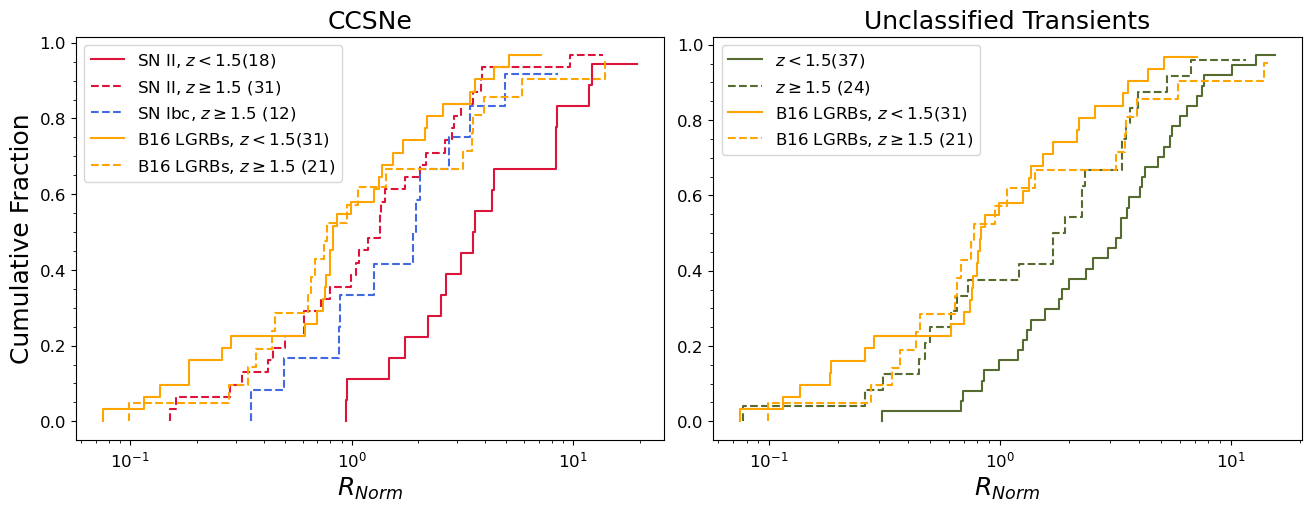

In [17]:
rnorm_maker(flights)

## Absolute Magnitudes

In [ ]:
def mag_maker(df, mag_type):
    
    mags = df[f"{pass_filter}"].astype(float).round(3) #cdf values of all the transients rounded to two decimal places
    mags_II = df.loc[df["Type"] == "II", f"{pass_filter}"].astype(float).round(2) #cdf values of type II SNe 
    mags_Ibc = df.loc[df["Type"] == "Ibc", f"{pass_filter}"].astype(float).round(2) #cdf values of Ibc SNe 
    mags_un = df.loc[df["Type"] == "Unclassified", f"{pass_filter}"].astype(float).round(2) #cdf values of Ibc SNe

    jades_mags = jades[f"{pass_filter}"].astype(float).round(3)
    jades_abs =[abs(x) for x in jades_mags]
    sorted_jades = np.sort(jades_abs)
    cdf_jades = np.arange(0, len(sorted_jades))/len(sorted_jades)
    jades_x = [-x for x in sorted_jades]

    fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(6.4, 5), constrained_layout=True)

    # cdfs for SNe - II
    II_abs = [abs(x) for x in mags_II] #converting negative magnitude to positive for sorting
    sorted_II = np.sort(II_abs)
    cdf_II = np.arange(1, len(sorted_II)+1)/len(sorted_II) #getting the cdf from the sorted list of positive magnitudes. This goes on the y axis
    II_x = [-x for x in sorted_II] #adding the negative sign back in for plotting. This goes on the x axis  

    # cdfs for SNe - Ibc 
    Ibc_abs =[abs(x) for x in mags_Ibc]
    sorted_Ibc = np.sort(Ibc_abs)
    cdf_Ibc = np.arange(1, len(sorted_Ibc)+1)/len(sorted_Ibc)
    Ibc_x = [-x for x in sorted_Ibc]

    # considering unclassified transients 
    un_abs = [abs(x) for x in mags_un] #converting negative magnitudes to positive for sorting
    sorted_un = np.sort(un_abs) # converting the negative values to positive for sorting
    cdf_un = np.arange(1, len(sorted_un)+1)/len(sorted_un)#getting the cdf of the sorted list of magnitudes
    un_x = [-x for x in sorted_un] #adding the negative sign back in

    # # # comparison sample LGRBs
    # grbs_samp = b16['R_phys']
    # grbb16_sorted = np.sort(grbs_samp)
    # cdf_grbb16 = np.arange(0, len(grbs_samp))/len(grbs_samp)

    ##making a plot of SN II, Ibc, and Unclassified separated
    axes.step(jades_x, cdf_jades, color="lightgrey", label="JADES galaxies" )
    axes.step(II_x, cdf_II, color='crimson', label=fr"II ({len(sorted_II)})")
    axes.step(Ibc_x, cdf_Ibc, color='royalblue', label=fr'Ibc ({len(sorted_Ibc)})')
    axes.step(un_x, cdf_un, color='darkolivegreen', label=fr'Unclassified ({len(sorted_un)})')
    axes.set_xlabel(fr"{mag_type}", fontsize=18)
    axes.set_ylabel("Cumulative Fraction", fontsize=18)
    axes.legend(fontsize=12)
    axes.tick_params(axis="both", which="major", labelsize=12)
    axes.invert_xaxis()

   ## adding samples from other papers 
    # axes[1].step(sorted_II, cdf_II, color='crimson', label=fr"II ({len(sorted_II)})")
    # axes[1].step(sorted_Ibc, cdf_Ibc, color='royalblue', label=fr'Ibc ({len(sorted_Ibc)})')
    # axes[1].step(sorted_un, cdf_un, color='darkolivegreen', label=fr'Unclassified ({len(sorted_un)})')
    # axes[1].step(grbb16_sorted, cdf_grbb16, color='darkturquoise', linestyle='--', label=fr'B16 LGRBs ({len(grbb16_sorted)})')
    # axes[1].step(slsne_sorted, cdf_slsne, color='darkviolet', linestyle='--', label = fr'H24 SLSNe ({len(slsne_sorted)})')
    # # axes[1].step(frbs_sorted, cdf_frbs, color='orange', linestyle='--', label=fr'W24 FRBs ({len(frbs_sorted)})')
    # axes[1].set_xlabel(r"$R_{Norm}$ (kpc)", fontsize=16)
    # axes[1].tick_params(axis="both", which="major", labelsize=12)
    # axes[1].legend(fontsize=12)
    # axes[1].set_xscale('log')

    # WITH REDSHIFT BINS 
    z1_ccsne = df.loc[(df['z'] >= 0) & (df['z'] < 1.5) & (df["Type"].isin(["II", "Ibc"])), f"{pass_filter}"].astype(float).round(2)
    z1_un = df.loc[(df['z'] >= 0) & (df['z'] < 1.5) & (df["Type"] == "Unclassified"), f"{pass_filter}"].astype(float).round(2)

    z2_ccsne = df.loc[(df['z'] >= 1.5) & (df['z'] < 2.5) & (df["Type"].isin(["II", "Ibc"])), f"{pass_filter}"].astype(float).round(2)
    z2_un = df.loc[(df['z'] >= 1.5) & (df['z'] < 2.5) & (df["Type"] == "Unclassified"), f"{pass_filter}"].astype(float).round(2)

    z3_ccsne = df.loc[(df['z'] >= 2.5) & (df["Type"].isin(["II", "Ibc"])), f"{pass_filter}"].astype(float).round(2)
    z3_un = df.loc[(df['z'] >= 2.5) & (df["Type"] == "Unclassified"), f"{pass_filter}"].astype(float).round(2)
    
    fig, zaxes = plt.subplots(nrows=1, ncols=2, figsize=(13, 5), constrained_layout=True)

   ## CCSNe
    z1_abs =[abs(x) for x in z1_ccsne]
    sorted_z1 = np.sort(z1_abs)
    cdf_z1 = np.arange(0, len(z1_ccsne))/len(z1_ccsne)
    z1_x = [-x for x in sorted_z1]

    z2_abs = [abs(x) for x in z2_ccsne]
    sorted_z2 = np.sort(z2_abs)
    cdf_z2 = np.arange(0, len(sorted_z2))/len(sorted_z2)
    z2_x =[-x for x in sorted_z2]

    z3_abs = [abs(x) for x in z3_ccsne]
    sorted_z3 = np.sort(z3_abs)
    cdf_z3 = np.arange(0, len(sorted_z3))/len(sorted_z3)
    z3_x = [-x for x in sorted_z3]

    # zaxes[0].plot(ref_sorted, ref_cdf, color='lightgrey')
    zaxes[0].step(z1_x, cdf_z1, color = 'orange', label= fr'$ z < 1.5 ({len(z1_ccsne)})$')
    zaxes[0].step(z2_x, cdf_z2, color = 'royalblue', label = fr'$1.5 \leq z < 2.5$ ({len(z2_ccsne)})')
    zaxes[0].step(z3_x, cdf_z3, color = 'mediumvioletred', label=fr'$z \geq 2.5$ ({len(z3_ccsne)})')
    zaxes[0].set_xlabel(fr"{mag_type}", fontsize=18)
    zaxes[0].set_ylabel("Cumulative Fraction", fontsize=18)
    zaxes[0].legend(fontsize=12)
    zaxes[0].tick_params(axis="both", which="major", labelsize=12)
    zaxes[0].set_title('CCSNe', fontsize=18)
    zaxes[0].invert_xaxis()

    # Unclassified transients 
    z1un_abs = [abs(x) for x in z1_un]
    sorted_z1_un = np.sort(z1un_abs)
    cdf_z1_un = np.arange(0, len(z1_un))/len(z1_un)
    z1un_x = [-x for x in sorted_z1_un]

    # # # cdfs for z between 1 (inclusive) and 3
    z2un_abs = [abs(x) for x in z2_un]
    sorted_z2_un = np.sort(z2un_abs)
    cdf_z2_un = np.arange(0, len(sorted_z2_un))/len(sorted_z2_un)
    z2un_x = [-x for x in sorted_z2_un]

    z3un_abs = [abs(x) for x in z3_un]
    sorted_z3_un = np.sort(z3un_abs)
    cdf_z3_un = np.arange(0, len(sorted_z3_un))/len(sorted_z3_un)
    z3un_x = [-x for x in sorted_z3_un]

    # zaxes[1].plot(ref_sorted, ref_cdf, color='lightgrey')
    zaxes[1].step(z1un_x, cdf_z1_un, color = 'orange', label= fr'$ z < 1.5 ({len(z1_un)})$')
    zaxes[1].step(z2un_x, cdf_z2_un, color = 'royalblue', label = fr'$1.5 \leq z < 2.5$ ({len(z2_un)})')
    zaxes[1].step(z3un_x, cdf_z3_un, color = 'mediumvioletred', label=fr'$z \geq 2.5$ ({len(z3_un)})')
    zaxes[1].set_xlabel(fr"{mag_type}", fontsize=18)
    zaxes[1].legend(fontsize=12)
    zaxes[1].tick_params(axis="both", which="major", labelsize=12)
    zaxes[1].set_title('Unclassified Transients', fontsize=18)
    zaxes[1].invert_xaxis()



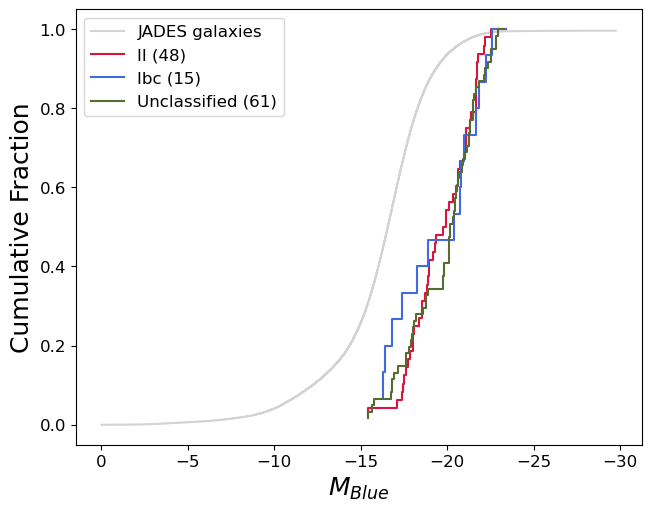

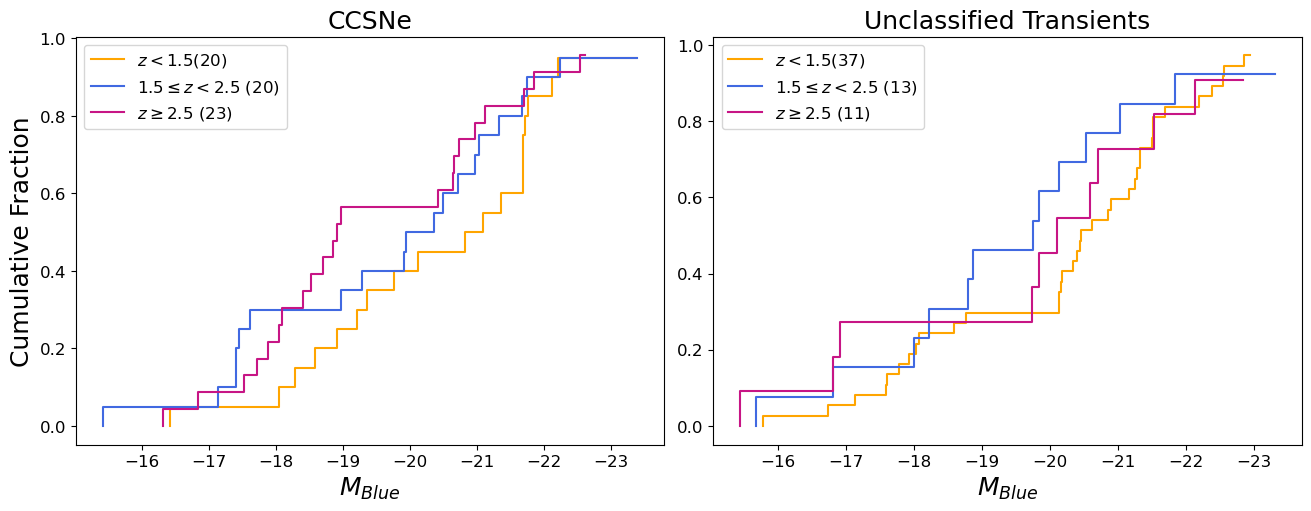

In [140]:
mag_maker(flights, r"$M_{Blue}$")

## $R_{50}$ (kpc)

In [43]:
def r50_maker(df): 

    cdfs = df[f"{pass_filter}"].astype(float).round(2) #cdf values of all the transients rounded to two decimal places
    cdf_II = df.loc[df["Type"] == "II", f"{pass_filter}"].astype(float).round(2).dropna() #cdf values of type II SNe 
    cdf_Ibc = df.loc[df["Type"] == "Ibc", f"{pass_filter}"].astype(float).round(2) #cdf values of Ibc SNe 
    cdf_un = df.loc[df["Type"] == "Unclassified", f"{pass_filter}"].astype(float).round(2) #cdf values of Ibc SNe 
    print(cdf_II)

    fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(6.5, 5), constrained_layout=True)

    # # considering only CCSNe
    # cdfs_classified = cdf_II.to_list() + cdf_Ibc.to_list()
    # sorted_classified = np.sort(cdfs_classified)
    # cdf_of_cdf_classified = np.arange(0, len(sorted_classified))/len(sorted_classified)

    # cdfs for unclassified sne 
    sorted_un = np.sort(cdf_un)
    cdf_un = np.arange(0, len(sorted_un))/len(sorted_un)

    # considering SN II
    sorted_II = np.sort(cdf_II)
    cdf_II = np.arange(0, len(sorted_II))/len(sorted_II)

    # considering SN Ibc
    sorted_Ibc = np.sort(cdf_Ibc)
    cdf_Ibc = np.arange(0, len(sorted_Ibc))/len(sorted_Ibc)

    # # comparison sample LGRBs
    grbs_samp = b16['r50_kpc']
    grbb16_sorted = np.sort(grbs_samp)
    cdf_grbb16 = np.arange(0, len(grbs_samp))/len(grbs_samp)

    # # comparison sample SLSNe 
    # slsne_samp = slsne['R50']
    # slsne_sorted = np.sort(slsne_samp)
    # cdf_slsne = np.arange(0,len(slsne_sorted))/len(slsne_sorted)

    kellyII_sorted = np.sort(kelly14_II)
    kellyII_cdf = np.arange(0, len(kellyII_sorted))/len(kellyII_sorted)

    # kellyIb_sorted = np.sort(kelly14_Ib)
    # kellyIb_cdf = np.arange(0, len(kellyIb_sorted))/len(kellyIb_sorted)

    # kellyIc_sorted = np.sort(kelly14_Ic)
    # kellyIc_cdf = np.arange(0, len(kellyIc_sorted))/len(kellyIc_sorted)

    kellyIbc_sorted = np.sort(kelly14_Ibc)
    kellyIbc_cdf = np.arange(0, len(kellyIbc_sorted))/len(kellyIbc_sorted)

    # kellyIcbl_sorted = np.sort(kelly14_Icbl)
    # kellyIcbl_cdf = np.arange(0, len(kellyIcbl_sorted))/len(kellyIcbl_sorted)

    # # comparison sample FRBs 
    # frbs_sorted = np.sort(frbs_2024)
    # cdf_frbs = np.arange(0, len(frbs_sorted))/len(frbs_sorted)

    ##making a plot of SN II, Ibc, and Unclassified separated
    # axes.step(sorted_II, cdf_II, color='crimson', label=fr"II ({len(sorted_II)})")
    # axes.step(sorted_Ibc, cdf_Ibc, color='royalblue', label=fr'Ibc ({len(sorted_Ibc)})')
    # axes.step(sorted_un, cdf_un, color='darkolivegreen', label=fr'Unclassified ({len(sorted_un)})')
    
    # axes.set_xscale("log")

   ## adding samples from other papers 
    axes.step(sorted_II, cdf_II, color='crimson', label=fr"II ({len(sorted_II)})")
    axes.step(sorted_Ibc, cdf_Ibc, color='royalblue', label=fr'Ibc ({len(sorted_Ibc)})')
    axes.step(sorted_un, cdf_un, color='darkolivegreen', label=fr'Unclassified ({len(sorted_un)})')
    axes.step(grbb16_sorted, cdf_grbb16, color='darkturquoise', linestyle='--', label=fr'B16 LGRBs ({len(grbb16_sorted)})')
    # axes.step(slsne_sorted, cdf_slsne, color='darkviolet', linestyle='--', label = fr'H24 SLSNe ({len(slsne_sorted)})')
    # kelly sample
    axes.step(kellyII_sorted, kellyII_cdf, color="crimson", linestyle='--', label=fr'K14 SN II ({len(kellyII_sorted)})')
    # axes.step(kellyIb_sorted, kellyIb_cdf, color="hotpink", linestyle='--', label=fr'K14 SN Ib ({len(kellyIb_sorted)})')
    # axes.step(kellyIc_sorted, kellyIc_cdf, color="lightskyblue", linestyle = '--', label=fr'K14 SN Ic ({len(kellyIc_sorted)})')
    axes.step(kellyIbc_sorted, kellyIbc_cdf, color="royalblue", linestyle='--', label=fr'K14 SN Ibc ({len(kellyIbc_sorted)})')
    # axes.step(kellyIcbl_sorted, kellyIcbl_cdf, color="orange", linestyle="--", label=fr'K14 SN Ic-BL ({len(kellyIcbl_sorted)})')
   

    # axes[1].step(frbs_sorted, cdf_frbs, color='orange', linestyle='--', label=fr'W24 FRBs ({len(frbs_sorted)})')
    # axes.set_xlabel(r"$R_{Norm}$ (kpc)", fontsize=19)
    # axes.tick_params(axis="both", which="major", labelsize=12)
    axes.set_xlabel(r"$R_{50}$ (kpc)", fontsize=19)
    axes.set_ylabel("Cumulative Fraction", fontsize=19)
    axes.tick_params(axis="both", which="major", labelsize=16)
    axes.legend(fontsize=14)
    axes.set_xscale('log')

    # WITH REDSHIFT BINS 
    z1_ccsne = df.loc[(df['z'] >= 0) & (df['z'] < 1.5) & (df["Type"].isin(["II", "Ibc"])), f"{pass_filter}"].astype(float).round(2)
    z1_un = df.loc[(df['z'] >= 0) & (df['z'] < 1.5) & (df["Type"] == "Unclassified"), f"{pass_filter}"].astype(float).round(2)

    z2_ccsne = df.loc[(df['z'] >= 1.5) & (df['z'] < 2.5) & (df["Type"].isin(["II", "Ibc"])), f"{pass_filter}"].astype(float).round(2)
    z2_un = df.loc[(df['z'] >= 1.5) & (df['z'] < 2.5) & (df["Type"] == "Unclassified"), f"{pass_filter}"].astype(float).round(2)

    z3_ccsne = df.loc[(df['z'] >= 2.5) & (df["Type"].isin(["II", "Ibc"])), f"{pass_filter}"].astype(float).round(2)
    z3_un = df.loc[(df['z'] >= 2.5) & (df["Type"] == "Unclassified"), f"{pass_filter}"].astype(float).round(2)
    
    fig, zaxes = plt.subplots(nrows=1, ncols=2, figsize=(13, 5), constrained_layout=True)

   ## CCSNe
    sorted_z1 = np.sort(z1_ccsne)
    cdf_z1 = np.arange(0, len(z1_ccsne))/len(z1_ccsne)

    # # # cdfs for z between 1 (inclusive) and 3
    sorted_z2 = np.sort(z2_ccsne)
    cdf_z2 = np.arange(0, len(sorted_z2))/len(sorted_z2)

    sorted_z3 = np.sort(z3_ccsne)
    cdf_z3 = np.arange(0, len(sorted_z3))/len(sorted_z3)

    # zaxes[0].plot(ref_sorted, ref_cdf, color='lightgrey')
    zaxes[0].step(sorted_z1, cdf_z1, color = 'orange', label= fr'$ z < 1.5 ({len(z1_ccsne)})$')
    zaxes[0].step(sorted_z2, cdf_z2, color = 'royalblue', label = fr'$1.5 \leq z < 2.5$ ({len(z2_ccsne)})')
    zaxes[0].step(sorted_z3, cdf_z3, color = 'mediumvioletred', label=fr'$z \geq 2.5$ ({len(z3_ccsne)})')
    zaxes[0].set_xlabel(r"$R_{50}$ (kpc)", fontsize=18)
    zaxes[0].set_ylabel("Cumulative Fraction", fontsize=18)
    zaxes[0].legend(fontsize=12)
    zaxes[0].tick_params(axis="both", which="major", labelsize=12)
    zaxes[0].set_title('CCSNe', fontsize=18)
    zaxes[0].set_xscale('log')

    # Unclassified transients 
    sorted_z1_un = np.sort(z1_un)
    cdf_z1_un = np.arange(0, len(z1_un))/len(z1_un)

    # # # cdfs for z between 1 (inclusive) and 3
    sorted_z2_un = np.sort(z2_un)
    cdf_z2_un = np.arange(0, len(sorted_z2_un))/len(sorted_z2_un)

    sorted_z3_un = np.sort(z3_un)
    cdf_z3_un = np.arange(0, len(sorted_z3_un))/len(sorted_z3_un)

    # zaxes[1].plot(ref_sorted, ref_cdf, color='lightgrey')
    zaxes[1].step(sorted_z1_un, cdf_z1_un, color = 'orange', label= fr'$ z < 1.5 ({len(z1_un)})$')
    zaxes[1].step(sorted_z2_un, cdf_z2_un, color = 'royalblue', label = fr'$1.5 \leq z < 2.5$ ({len(z2_un)})')
    zaxes[1].step(sorted_z3_un, cdf_z3_un, color = 'mediumvioletred', label=fr'$z \geq 2.5$ ({len(z3_un)})')
    zaxes[1].set_xlabel(r"$R_{50}$ (kpc)", fontsize=18)
    zaxes[1].legend(fontsize=12)
    zaxes[1].tick_params(axis="both", which="major", labelsize=12)
    zaxes[1].set_title('Unclassified Transients', fontsize=18)
    zaxes[1].set_xscale('log')

    return 



0     1.80
1     4.43
2     4.57
3     0.60
5     0.75
8     0.85
11    2.42
14    2.28
15    2.05
16    1.04
17    1.70
18    1.55
19    1.89
20    1.96
21    2.70
22    1.43
23    2.49
25    3.22
26    1.84
27    5.67
28    5.23
29    4.47
30    2.43
31    2.21
32    4.57
33    3.76
34    1.61
35    0.86
37    1.24
39    0.86
40    1.17
42    1.53
44    1.41
47    1.59
48    1.29
49    1.82
50    1.54
51    1.45
55    2.64
56    1.96
57    2.09
58    2.47
59    1.20
63    4.57
64    2.06
99    1.68
Name: r50_kpc, dtype: float64


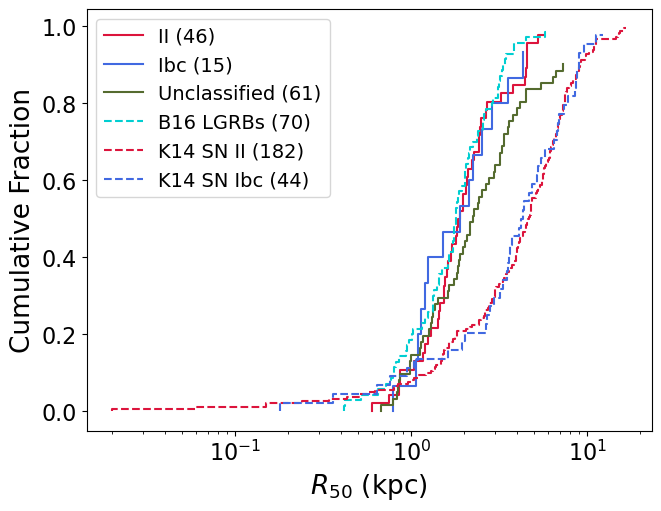

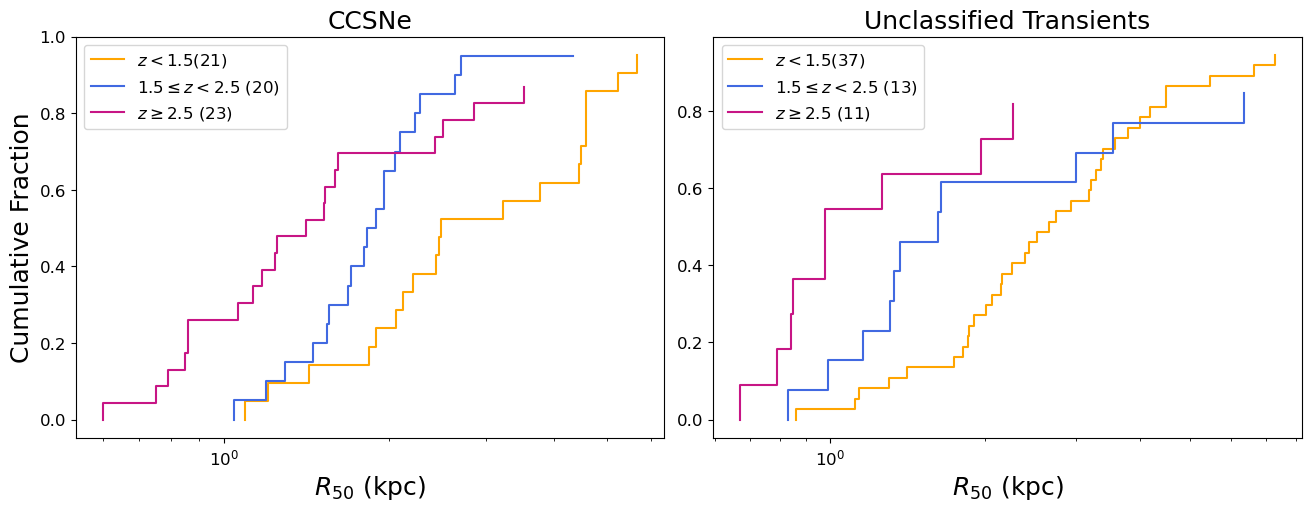

In [44]:
r50_maker(flights)

## Segregate

In [75]:
def segregate(transient_cdfs, sne_type=None, host_z=None):
   
    plot_label = None
    cfds = None
    # conditions for all SNe cdfs 
    if sne_type is None and host_z is None:
        cdfs = transient_cdfs[fr"{pass_filter}"].astype(float).round(2)
        # plot_label = f"{len(cdfs)} SNe"
    
    # condition for different z ranges 
    elif sne_type is None:
        cdfs = transient_cdfs.loc[
            (transient_cdfs['z'] >= host_z[0]) & 
            (transient_cdfs['z']<host_z[1]), 
            fr"{pass_filter}"
            ].astype(float).round(2)
        # plot_label = f'${host_z[0]} \leq z < {host_z[1]} ({len(cdfs)})$'

    # condition for different SNe types 
    elif host_z is None:
        cdfs = transient_cdfs.loc[transient_cdfs["Type"].isin(sne_type), fr"{pass_filter}"].astype(float).round(2)
        # plot_label = f'{sne_type} ({len(cdfs)})'

    # condition for different SNe types over Z ranges 
    else: 
        cdfs = transient_cdfs.loc[
            (transient_cdfs['Type'].isin(sne_type)) &
            (transient_cdfs['z'] >= host_z[0]) &
            (transient_cdfs['z'] < host_z[1]),
            fr"{pass_filter}"
        ].astype(float).round(2)
        # plot_label = f"$ {sne_type}, {host_z[0]} \leq z < {host_z[1]} ({len(cdfs)})$"
    
    sorted_cdfs = np.sort(cdfs)
    c = np.arange(0, len(sorted_cdfs))/len(sorted_cdfs)

    # ref = stats.uniform.rvs(size=10000)
    # ref_sorted = np.sort(ref)
    # ref_cdf = np.arange(0, len(ref_sorted))/len(ref_sorted)

    plt.figure(figsize=(5, 3.5))
    # plt.plot(ref_sorted, ref_cdf, color='silver')
    plt.step(sorted_cdfs, c, color='r', label = plot_label)
    plt.title(plot_label)
    plt.xlabel(r"$f_{\text{light}}$")
    plt.xscale('log')

    plt.ylabel("CDF")
    plt.legend()
    plt.show()

    
    cdf_values = cdfs.to_numpy()

    # # **comment out when pulling mags 
    # ad = stats.anderson_ksamp([cdfs, ref], method=stats.PermutationMethod())
    # print(fr"AD Statistic:", ad.statistic)
    # print(fr"AD  level (p-value approx.):", ad.pvalue)
    # print("Critical Values (25%, 10%, 5%, 2.5%, 1%, 0.5%, 0.1%):")
    # print(ad.critical_values)
   
    # ks_stat = stats.kstest(cdf_values, 'uniform')
    # print("KS Statistic:", ks_stat.statistic)
    # print("KS  level (p-value approx.):", ks_stat.pvalue)
    # print(len(cdfs))
    return cdfs

C:\Users\Rujuta\AppData\Local\Temp\ipykernel_34788\3634369469.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


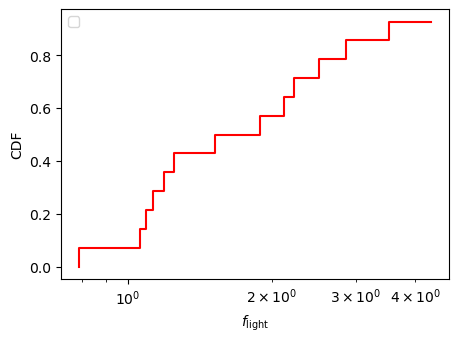

In [76]:
Z1 = segregate(flights, sne_type=["Ibc"])

In [77]:
print(Z1)

4     1.06
6     0.79
7     2.86
10    3.52
24    1.89
36    1.25
38    1.13
41    1.52
43    2.51
52    4.32
53    2.23
54    1.19
60    1.09
61    2.12
Name: r50_kpc, dtype: float64


In [78]:
z_test = stats.anderson_ksamp([Z1.dropna(), kelly14_Ibc], midrank=True, method=stats.PermutationMethod())
print(z_test)
print(f"Approx. p-value = {z_test.pvalue:.4f}")

kstest = stats.ks_2samp(Z1.dropna(), kelly14_Ibc, method='auto')
print(kstest)

Anderson_ksampResult(statistic=7.429014101344256, critical_values=array([0.325, 1.226, 1.961, 2.718, 3.752, 4.592, 6.546]), pvalue=0.0005)
Approx. p-value = 0.0005
KstestResult(statistic=0.5844155844155844, pvalue=0.0006535340430944376, statistic_location=2.86, statistic_sign=1)


## Segregate MAGS

In [74]:
def segregate_mags(transient_cdfs, sne_type=None, host_z=None):
   
    plot_label = None
    cfds = None
    # conditions for all SNe cdfs 
    if sne_type is None and host_z is None:
        cdfs = transient_cdfs[fr"{pass_filter}"].astype(float).round(2)
        # plot_label = f"{len(cdfs)} SNe"
    
    # condition for different z ranges 
    elif sne_type is None:
        cdfs = transient_cdfs.loc[
            (transient_cdfs['z'] >= host_z[0]) & 
            (transient_cdfs['z']<host_z[1]), 
            fr"{pass_filter}"
            ].astype(float).round(2)
        # plot_label = f'${host_z[0]} \leq z < {host_z[1]} ({len(cdfs)})$'

    # condition for different SNe types 
    elif host_z is None:
        cdfs = transient_cdfs.loc[transient_cdfs["Type"].isin(sne_type), fr"{pass_filter}"].astype(float).round(2)
        # plot_label = f'{sne_type} ({len(cdfs)})'

    # condition for different SNe types over Z ranges 
    else: 
        cdfs = transient_cdfs.loc[
            (transient_cdfs['Type'].isin(sne_type)) &
            (transient_cdfs['z'] >= host_z[0]) &
            (transient_cdfs['z'] < host_z[1]),
            fr"{pass_filter}"
        ].astype(float).round(2)
        # plot_label = f"$ {sne_type}, {host_z[0]} \leq z < {host_z[1]} ({len(cdfs)})$"
    
    cdfs_abs =[abs(x) for x in cdfs]
    sorted_cdfs = np.sort(cdfs_abs)
    c = np.arange(0, len(sorted_cdfs))/len(sorted_cdfs)
    cdfs_x = [-x for x in sorted_cdfs]

    
    plt.figure(figsize=(5, 3.5))
    plt.step(cdfs_x, c, color='r', label = plot_label)
    plt.title(plot_label)
    plt.xlabel(r"M")
    # plt.xscale('log')
    plt.ylabel("CDF")
    plt.legend()
    
    plt.show()

    return cdfs

C:\Users\Rujuta\AppData\Local\Temp\ipykernel_34556\2398983952.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


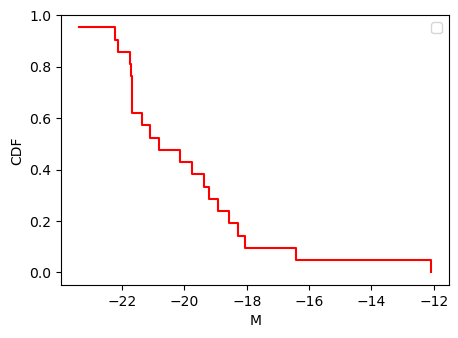

In [77]:
Z1 = segregate_mags(flights, sne_type=["II", "Ibc"], host_z=[0,1.5])

Scatter (std of residuals) = 0.178
Slope = 0.7487820210361537
Intercept = 0.15496566274645623
Standard deviation (blue) = 0.29141795140313503
Standard deviation (IR) = 0.28160581198547735
Spearman r = 0.771
p-value    = 0.0000000
Result: statistically significant correlation


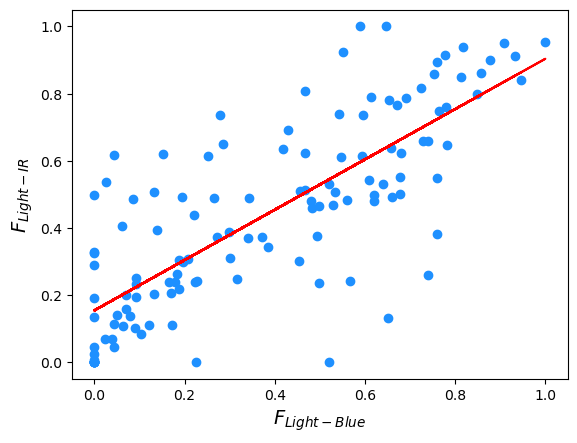

In [176]:
# plotting blue vs IR correlation

blue_list = transients_filtered['blue']
ir_list = transients_filtered['ir']

plt.scatter(blue_list, ir_list, color='dodgerblue')
plt.xlabel(r"$F_{Light-Blue}$", fontsize=14)
plt.ylabel(r"$F_{Light-IR}$", fontsize=14)
# plt.savefig("mag_flight_correlation/blueIir_flight.png", dpi=300)

m, b = np.polyfit(blue_list, ir_list, 1)
y_fit = m*blue_list + b 
residuals = ir_list - y_fit
scatter = np.std(residuals)
print(f'Scatter (std of residuals) = {scatter:.3f}')

plt.plot(blue_list, y_fit, color='r')
print(f"Slope = {m}")
print(f"Intercept = {b}")
print(f"Standard deviation (blue) = {np.std(blue_list)}")
print(f"Standard deviation (IR) = {np.std(ir_list)}")

correlation, p_value = stats.spearmanr(blue_list, ir_list)

print(f'Spearman r = {correlation:.3f}')
print(f'p-value    = {p_value:.7f}')

if p_value < 0.05:
    print('Result: statistically significant correlation')
else:
    print('Result: no statistically significant correlation')

Spearman r = nan
p-value    = nan
Result: no statistically significant correlation


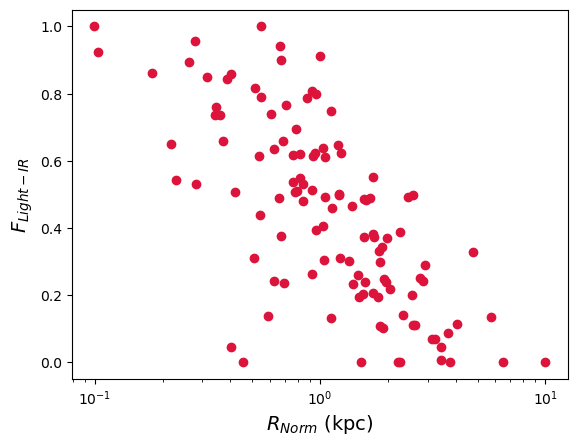

In [177]:
# correlation flight vs host normalized offset 

offset_list = transients_filtered['R_norm']
plt.scatter(offset_list, ir_list, color='crimson')
plt.xlabel(r"$R_{Norm}$ (kpc)", fontsize=14)
plt.ylabel(r"$F_{Light-IR}$", fontsize=14)
plt.xscale('log')

correlation, p_value = stats.spearmanr(offset_list, ir_list)

print(f'Spearman r = {correlation:.3f}')
print(f'p-value    = {p_value:.7f}')

if p_value < 0.05:
    print('Result: statistically significant correlation')
else:
    print('Result: no statistically significant correlation')

In [230]:
from matplotlib.gridspec import GridSpec

In [248]:
transients_filtered = transients_filtered.drop(62)

In [46]:
jades_2 = 'G:\Supernova_project\Data\Catalogs\hlsp_jades_jwst_nircam_goods-s-deep_photometry_v2.0_catalog.fits'
catalog_file = fits.open(jades_2)
catalog_file.info()

Filename: G:\Supernova_project\Data\Catalogs\hlsp_jades_jwst_nircam_goods-s-deep_photometry_v2.0_catalog.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      13   ()      
  1  FILTERS       1 BinTableHDU     33   23R x 12C   [6A, E, E, E, E, E, E, E, E, E, E, E]   
  2  FLAG          1 BinTableHDU    161   94000R x 75C   [J, D, D, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, I, E, E]   
  3  SIZE          1 BinTableHDU    100   94000R x 43C   [J, D, D, E, D, D, D, D, J, J, J, J, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E]   
  4  CIRC          1 BinTableHDU    856   94000R x 423C   [J, D, D, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, 

<>:1: SyntaxWarning: invalid escape sequence '\S'
<>:1: SyntaxWarning: invalid escape sequence '\S'
C:\Users\Rujuta\AppData\Local\Temp\ipykernel_34788\2443004471.py:1: SyntaxWarning: invalid escape sequence '\S'
  jades_2 = 'G:\Supernova_project\Data\Catalogs\hlsp_jades_jwst_nircam_goods-s-deep_photometry_v2.0_catalog.fits'


In [47]:
size_data = Table(catalog_file['SIZE'].data)
size_data

ID,RA,DEC,NPIX_DET,X,Y,XC,YC,BBOX_XMIN,BBOX_XMAX,BBOX_YMIN,BBOX_YMAX,R_KRON,R_KRON_S,PA,Q,A,B,FWHM,GINI,F090W_RHALF,F115W_RHALF,F150W_RHALF,F182M_RHALF,F200W_RHALF,F210M_RHALF,F277W_RHALF,F335M_RHALF,F356W_RHALF,F410M_RHALF,F430M_RHALF,F444W_RHALF,F460M_RHALF,F480M_RHALF,F435W_RHALF,F606W_RHALF,F775W_RHALF,F814W_RHALF,F850LP_RHALF,F105W_RHALF,F125W_RHALF,F140W_RHALF,F160W_RHALF
uint32,float64,float64,float32,float64,float64,float64,float64,uint32,uint32,uint32,uint32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32
519,53.11341212289474,-27.923778367040864,178.0,12917.056232326719,2553.797411527974,12917.437351959676,2553.6169745409156,12910,12926,2546,2561,0.3070113,0.14736542,33.154137,0.9242004,0.09434537,0.087194026,0.21391208,0.40688744,0.13265936,0.13265936,0.13265936,0.13265936,0.13265936,0.13265936,0.13265936,0.13265936,0.13265936,0.13265936,0.13265936,0.13265936,0.13265936,0.13265936,0.13265936,0.13265936,0.13265936,0.13265936,0.13265936,0.13265936,0.13265936,0.13265936,0.13265936
522,53.11363907631932,-27.923760491623977,196.0,12892.988576904854,2555.9446674189276,12893.108851002718,2556.767349189687,12884,12901,2549,2565,0.30258814,0.14524232,23.090853,0.81531435,0.12236987,0.099769905,0.2628997,0.2285922,0.2168504,0.2168504,0.2168504,0.2168504,0.2168504,0.2168504,0.2168504,0.2168504,0.2168504,0.2168504,0.2168504,0.2168504,0.2168504,0.2168504,0.2168504,0.2168504,0.2168504,0.2168504,0.2168504,0.2168504,0.2168504,0.2168504,0.2168504
528,53.113291495408944,-27.923707973106126,38.0,12929.849113392389,2562.2452146312417,12929.943678802254,2562.4024916389103,12927,12933,2560,2565,0.13571218,0.06514184,-13.770763,0.845924,0.049810965,0.04213629,0.10863608,0.2554773,0.11302999,0.11302999,0.11302999,0.11302999,0.11302999,0.11302999,0.11302999,0.11302999,0.11302999,0.11302999,0.11302999,0.11302999,0.11302999,0.11302999,0.11302999,0.11302999,0.11302999,0.11302999,0.11302999,0.11302999,0.11302999,0.11302999,0.11302999
529,53.113659821274354,-27.923673664324607,120.0,12890.789402373886,2566.365978426608,12890.8298349846,2566.411069328334,12884,12898,2560,2574,0.1979507,0.095016345,39.017376,0.5699153,0.10794352,0.061518665,0.20687835,0.30422235,0.12621357,0.12621357,0.12621357,0.12621357,0.12621357,0.12621357,0.12621357,0.12621357,0.12621357,0.12621357,0.12621357,0.12621357,0.12621357,0.12621357,0.12621357,0.12621357,0.12621357,0.12621357,0.12621357,0.12621357,0.12621357,0.12621357,0.12621357
538,53.11370277246355,-27.923571621702475,206.0,12886.235442281057,2578.6136305037476,12886.34659712766,2577.2428345663916,12879,12892,2567,2589,0.27575186,0.1323609,-84.95676,0.644239,0.14198874,0.09147469,0.28124294,0.2735164,0.32773158,0.32773158,0.32773158,0.32773158,0.32773158,0.32773158,0.32773158,0.32773158,0.32773158,0.32773158,0.32773158,0.32773158,0.32773158,0.32773158,0.32773158,0.32773158,0.32773158,0.32773158,0.32773158,0.32773158,0.32773158,0.32773158,0.32773158
549,53.11399120971899,-27.923411037494503,464.0,12855.648749279855,2597.8894288551733,12854.888781401016,2598.7891818649955,12838,12866,2587,2612,0.4077776,0.19573326,-44.159027,0.62546957,0.18085892,0.113121755,0.35520524,0.4601047,0.19168559,0.19168559,0.19168559,0.19168559,0.19168559,0.19168559,0.19168559,0.19168559,0.19168559,0.19168559,0.19168559,0.19168559,0.19168559,0.19168559,0.19168559,0.19168559,0.19168559,0.19168559,0.19168559,0.19168559,0.19168559,0.19168559,0.19168559
550,53.1136670777497,-27.92344334468529,140.0,12890.021922617505,2594.0093549253193,12890.265943291903,2593.7762469601944,12882,12897,2587,2602,0.27301612,0.13104774,49.582504,0.92923576,0.10585741,0.098366484,0.24061698,0.25900745,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
560,53.112939903264746,-27.923323312786135,75.0,12967.138260860907,2608.4097

In [48]:
z_data = Table(catalog_file['PHOTOZ'].data)
z_data

ID,EAZY_z_a,EAZY_chisq_min,EAZY_l68,EAZY_u68,EAZY_l95,EAZY_u95,EAZY_l99,EAZY_u99,EAZY_nfilt
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64
519,0.86,2.356956,0.779,1.03,0.665,1.239,0.078,3.065,13.0
522,4.23,2.749311,3.47,4.851,0.836,5.46,0.374,5.886,13.0
528,4.94,11.68597,2.039,12.117,0.815,16.467,0.184,21.419,13.0
529,0.69,11.37277,3.869,4.564,0.649,4.77,0.412,4.87,13.0
538,3.84,3.458545,3.521,4.161,0.411,4.44,0.287,4.705,13.0
549,0.54,4.743541,0.19,0.821,0.105,2.084,0.068,3.061,13.0
550,0.72,22.04849,0.263,2.762,0.074,3.164,0.013,3.914,13.0
560,4.86,4.328593,1.964,5.368,0.757,5.926,0.082,6.81,13.0
615,0.79,3.836787,0.666,0.92,0.46,4.669,0.238,4.891,13.0


In [49]:
size_df = Table(catalog_file['SIZE'].data).to_pandas()
z_df = Table(catalog_file['PHOTOZ'].data).to_pandas()

# Keep only objects with 0 <= z <= 6
z_df = z_df[(z_df["EAZY_z_a"] >= 0) & (z_df["EAZY_z_a"] <= 6)]

# Merge on ID
merged_df = size_df[["ID","F090W_RHALF"]].merge(
    z_df[["ID", "EAZY_z_a"]],
    on="ID",
    how="inner"
)

In [50]:
merged_df.columns

Index(['ID', 'F090W_RHALF', 'EAZY_z_a'], dtype='object')

In [51]:
import astropy.units as u

In [52]:
r50_kpc = []

for i, r in merged_df['F090W_RHALF'].items():
    scale = cosmo.kpc_proper_per_arcmin(merged_df.loc[i, 'EAZY_z_a']).to(u.kpc/u.arcsec).value
    r_50 = round((scale*r).item(), 3)
    r50_kpc.append(r_50)


In [53]:
merged_df["R50"] = r50_kpc
merged_df = merged_df.dropna()


In [54]:
merged_df = merged_df[merged_df["R50"] < 8]

In [55]:
transients_filtered = transients_filtered.dropna()

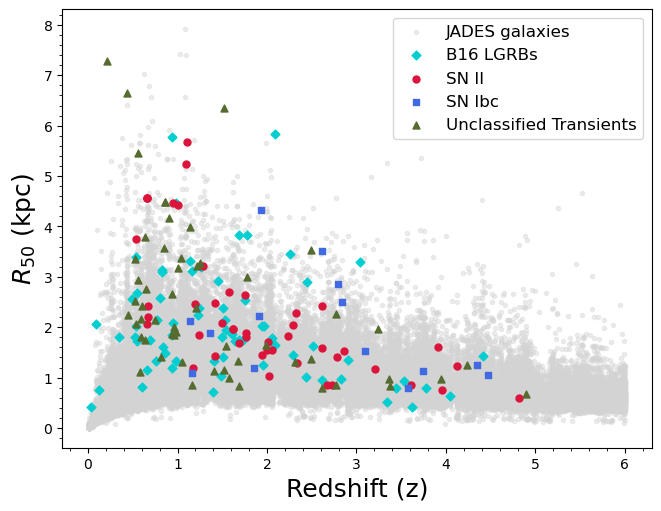

In [ ]:

fig, size = plt.subplots(nrows=1, ncols=1, figsize=(6.5, 5), constrained_layout=True)

z_II = transients_filtered.loc[transients_filtered["Type"] == "II", "z"].astype(float).round(2) #cdf values of type II SNe 
z_Ibc = transients_filtered.loc[transients_filtered["Type"] == "Ibc", "z"].astype(float).round(2) #cdf values of Ibc SNe 
z_un = transients_filtered.loc[transients_filtered["Type"] == "Unclassified", "z"].astype(float).round(2) #cdf values of Ibc SNe

r_II = transients_filtered.loc[transients_filtered["Type"] == "II", f"r50_kpc"].astype(float).round(2) #cdf values of type II SNe
r_Ibc = transients_filtered.loc[transients_filtered["Type"] == "Ibc", f"r50_kpc"].astype(float).round(2) #cdf values of Ibc SNe 
r_un = transients_filtered.loc[transients_filtered["Type"] == "Unclassified", f"r50_kpc"].astype(float).round(2) #cdf values of Ibc SNe 

size.scatter(merged_df["EAZY_z_a"], merged_df["R50"], color="lightgrey", marker='.', alpha=0.4, label="JADES galaxies" )
# size.scatter(kelly14['z'], kelly14['R50'], color='orange', marker = "D", s=25, label="K14 CCSNe")
# size.scatter(slsne['Redshift'], slsne['R50'], color="darkviolet", marker = "*", s = 25, label="H24 SLSNe")
size.scatter(b16.loc[b16['z'] <6, "z"], b16.loc[b16["z"] < 6, 'r50_kpc'], color="darkturquoise", marker="D", s=20, label="B16 LGRBs")

size.scatter(z_II, r_II, color="crimson", marker ="o", s=25, label="SN II")
size.scatter(z_Ibc, r_Ibc, color="royalblue", marker ="s", s=25, label = "SN Ibc")
size.scatter(z_un, r_un, color="darkolivegreen", marker = "^", s=25, label = "Unclassified Transients")



# plt.scatter(transients_filtered["M_IR"], transients_filtered["r50_kpc"], color="crimson")
size.set_xlabel(r"Redshift (z)", fontsize=18)
size.set_ylabel(r"$R_{50}$ (kpc)", fontsize=18)
# size.set_yscale('log')
size.minorticks_on()
size.legend(fontsize=12)
# size.invert_xaxis()